# INX Future Inc — Employee Performance Analysis
## Notebook 2: Exploratory Data Analysis (EDA)
**Project Code:** 10281 | **IABAC Certified Data Scientist Project**

In [7]:
# pip install xlrd

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
df = pd.read_excel('D:/AI COURSE/Daily_practice/PROJECTS/INX_Employee_Performance/data/raw/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1_8.xls')
print(f'Data loaded: {df.shape}')

Data loaded: (1200, 28)


## 1. Target Variable Distribution

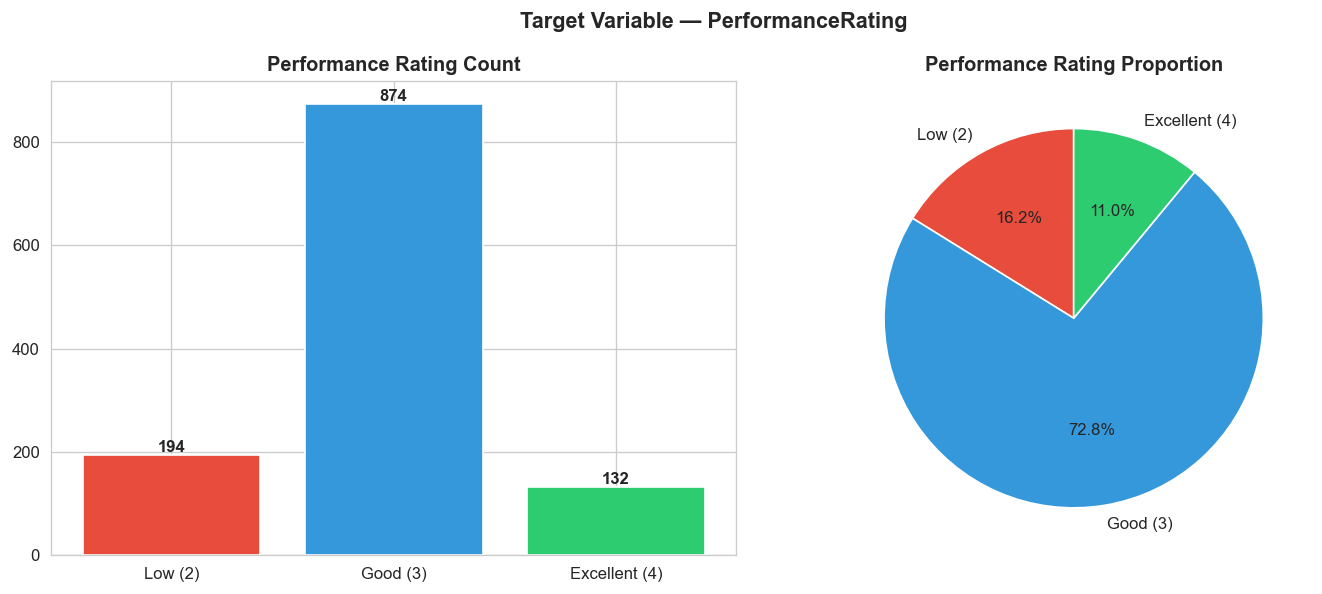

Class imbalance present — SMOTE applied during modeling.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
counts = df['PerformanceRating'].value_counts().sort_index()
colors = ['#e74c3c','#3498db','#2ecc71']
labels = ['Low (2)','Good (3)','Excellent (4)']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Performance Rating Count', fontweight='bold')
for i,v in enumerate(counts.values): axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Performance Rating Proportion', fontweight='bold')
plt.suptitle('Target Variable — PerformanceRating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_target_distribution.png', bbox_inches='tight')
plt.show()
print('Class imbalance present — SMOTE applied during modeling.')

## 2. Department-wise Performance (Business Requirement #1)

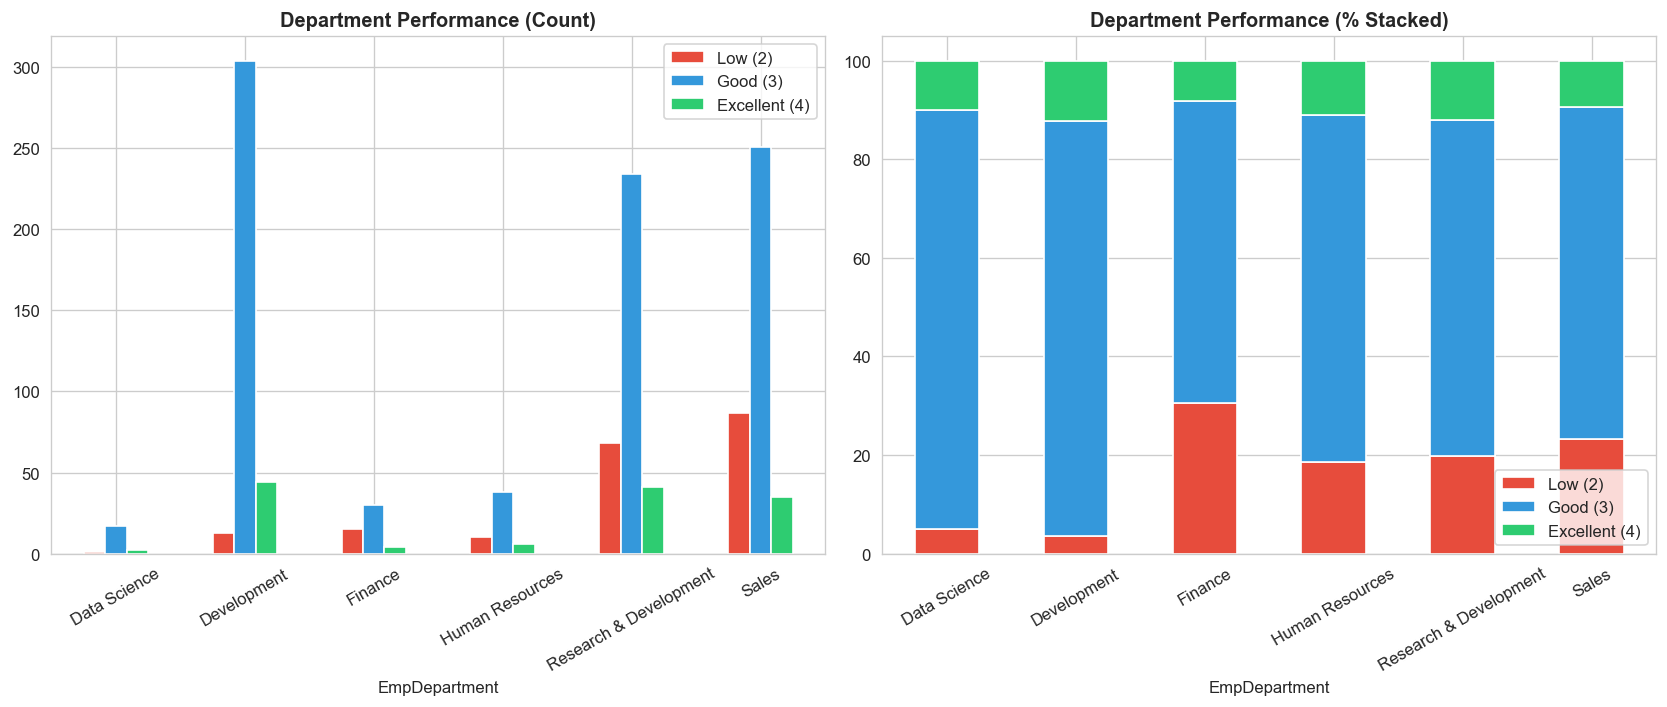

                        Low (2)  Good (3)  Excellent (4)
EmpDepartment                                           
Data Science                5.0      85.0           10.0
Development                 3.6      84.2           12.2
Finance                    30.6      61.2            8.2
Human Resources            18.5      70.4           11.1
Research & Development     19.8      68.2           12.0
Sales                      23.3      67.3            9.4


In [10]:
dept_perf = df.groupby(['EmpDepartment','PerformanceRating']).size().unstack(fill_value=0)
dept_perf.columns = ['Low (2)','Good (3)','Excellent (4)']
dept_pct = dept_perf.div(dept_perf.sum(axis=1), axis=0)*100
fig, axes = plt.subplots(1, 2, figsize=(14,6))
dept_perf.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title('Department Performance (Count)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
dept_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1].set_title('Department Performance (% Stacked)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../../data/processed/fig_department_performance.png', bbox_inches='tight')
plt.show()
print(dept_pct.round(1))

## 3. Correlation Heatmap

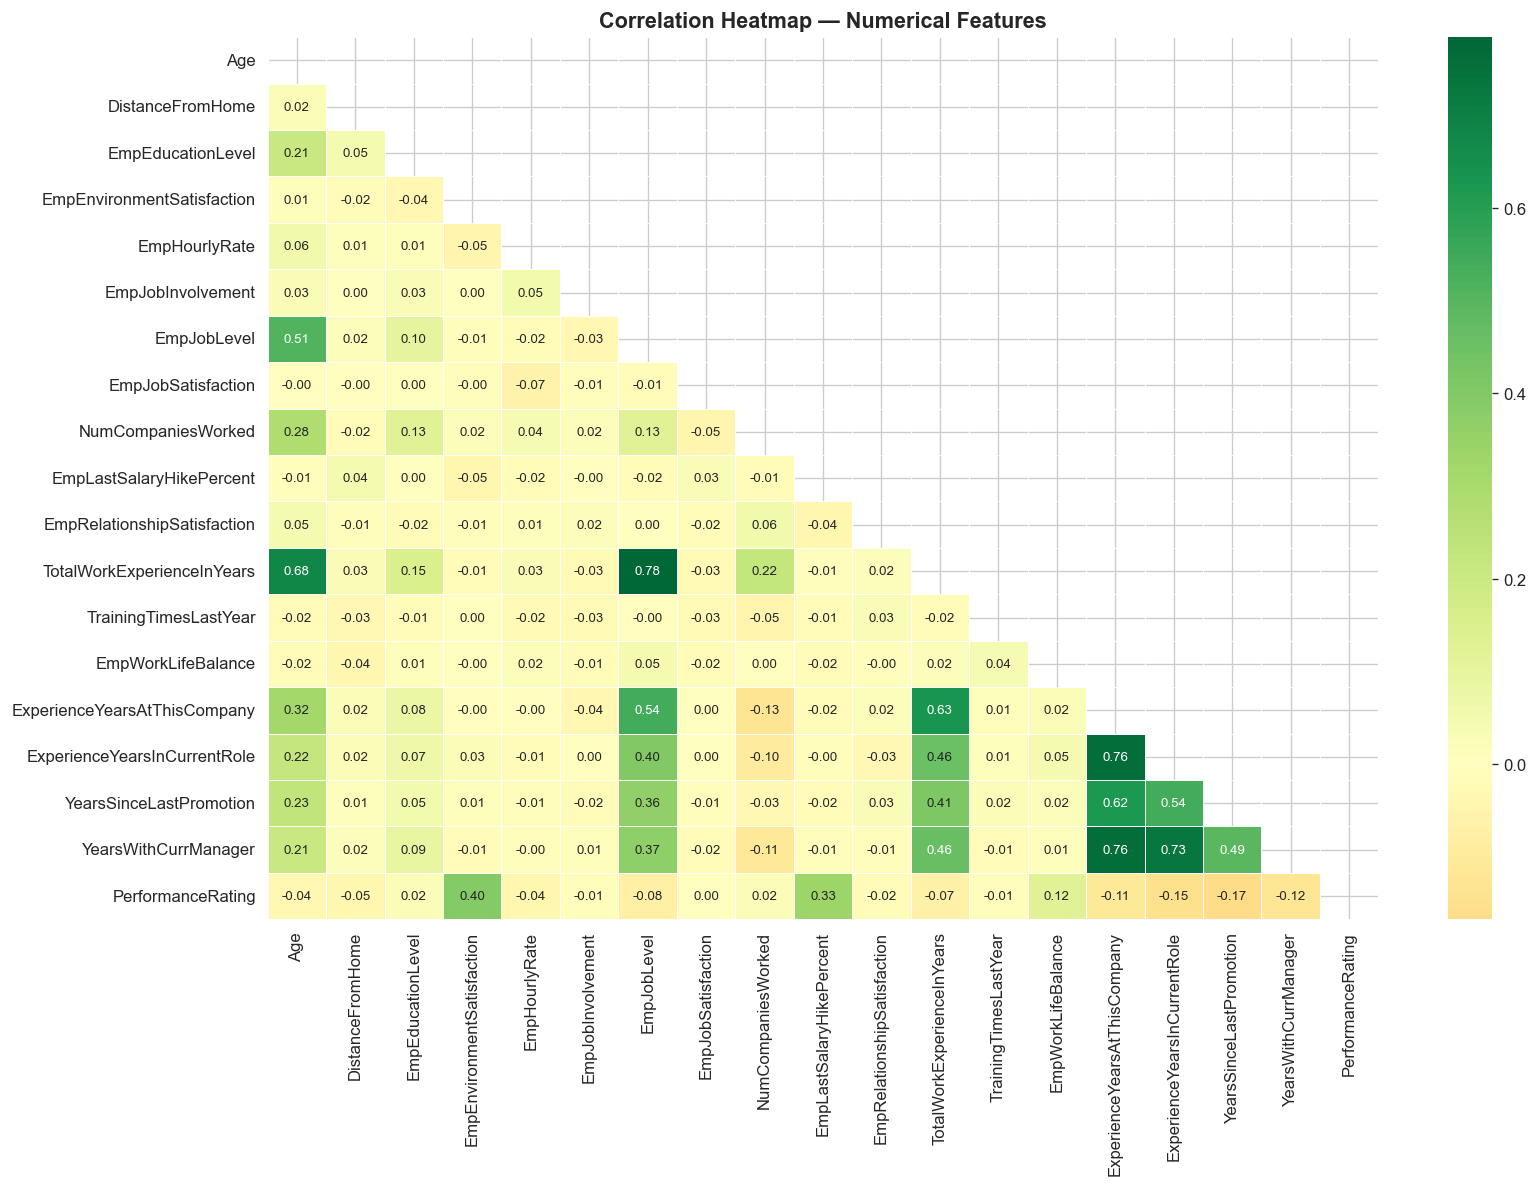

Top correlations with PerformanceRating:
EmpEnvironmentSatisfaction      0.396
EmpLastSalaryHikePercent        0.334
YearsSinceLastPromotion        -0.168
ExperienceYearsInCurrentRole   -0.148
EmpWorkLifeBalance              0.124
YearsWithCurrManager           -0.122
ExperienceYearsAtThisCompany   -0.112
EmpJobLevel                    -0.077
TotalWorkExperienceInYears     -0.068
DistanceFromHome               -0.046
Name: PerformanceRating, dtype: float64


In [11]:
num_df = df.select_dtypes(include=['int64','float64'])
corr = num_df.corr()
plt.figure(figsize=(14,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size':8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()
target_corr = corr['PerformanceRating'].drop('PerformanceRating').sort_values(key=abs, ascending=False)
print('Top correlations with PerformanceRating:')
print(target_corr.head(10).round(3))

## 4. Key Features vs Performance Rating

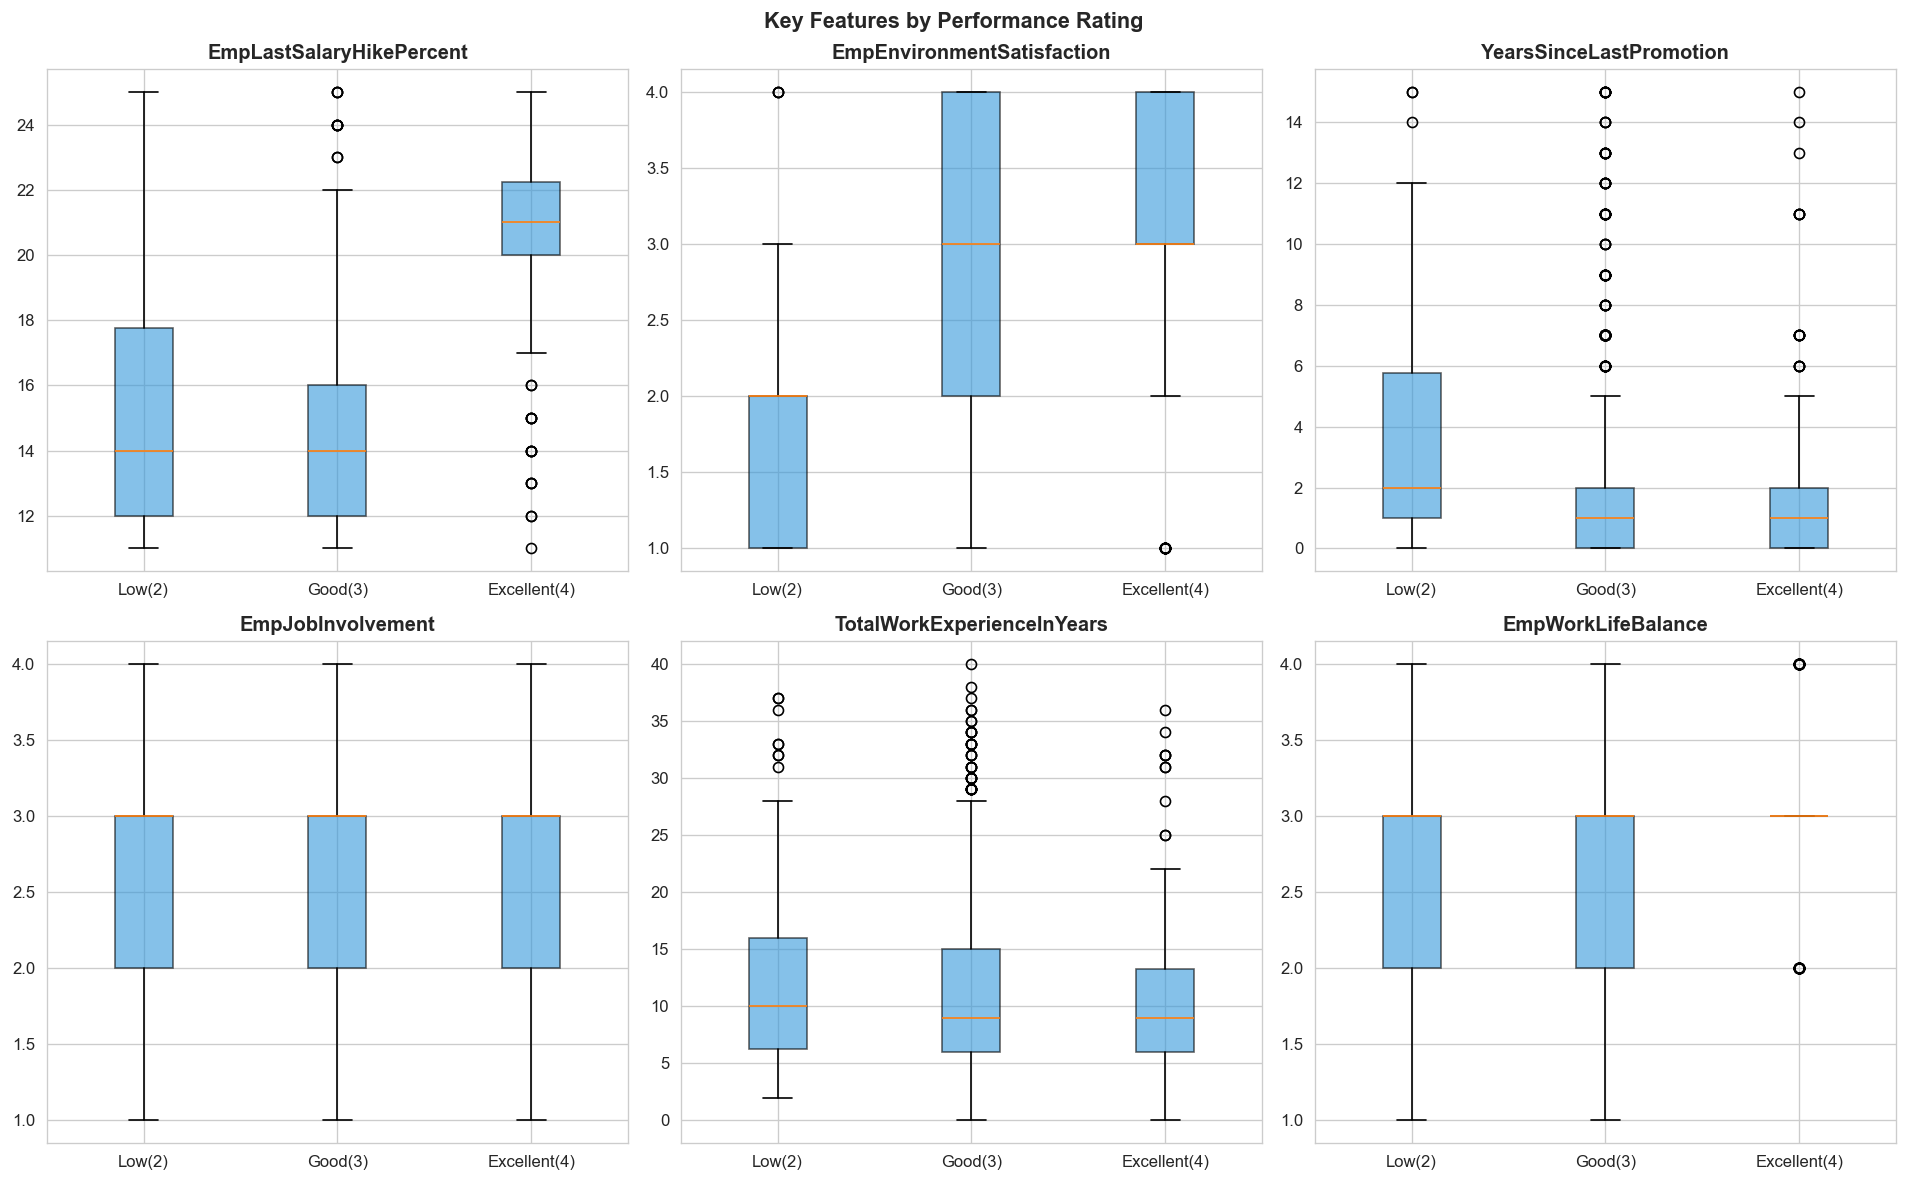

In [12]:
feats = ['EmpLastSalaryHikePercent','EmpEnvironmentSatisfaction','YearsSinceLastPromotion',
         'EmpJobInvolvement','TotalWorkExperienceInYears','EmpWorkLifeBalance']
fig, axes = plt.subplots(2, 3, figsize=(16,10))
for ax, feat in zip(axes.flatten(), feats):
    data_plot = [df[df['PerformanceRating']==r][feat].values for r in [2,3,4]]
    ax.boxplot(data_plot, labels=['Low(2)','Good(3)','Excellent(4)'], patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(feat, fontweight='bold')
plt.suptitle('Key Features by Performance Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_feature_vs_performance.png', bbox_inches='tight')
plt.show()

## 5. OverTime & Attrition Impact

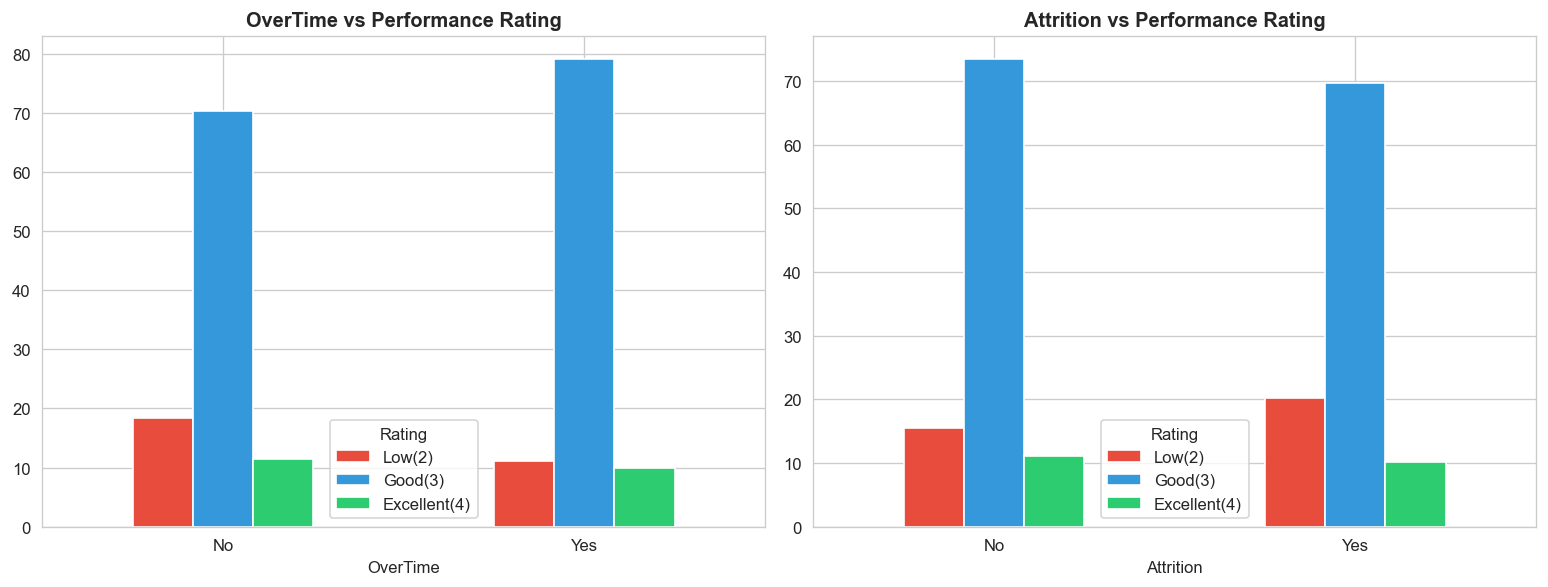

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, col in zip(axes, ['OverTime','Attrition']):
    ct = pd.crosstab(df[col], df['PerformanceRating'], normalize='index')*100
    ct.columns = ['Low(2)','Good(3)','Excellent(4)']
    ct.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
    ax.set_title(f'{col} vs Performance Rating', fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Rating')
plt.tight_layout()
plt.savefig('../../data/processed/fig_overtime_attrition.png', bbox_inches='tight')
plt.show()

## 6. Age & Experience Distributions

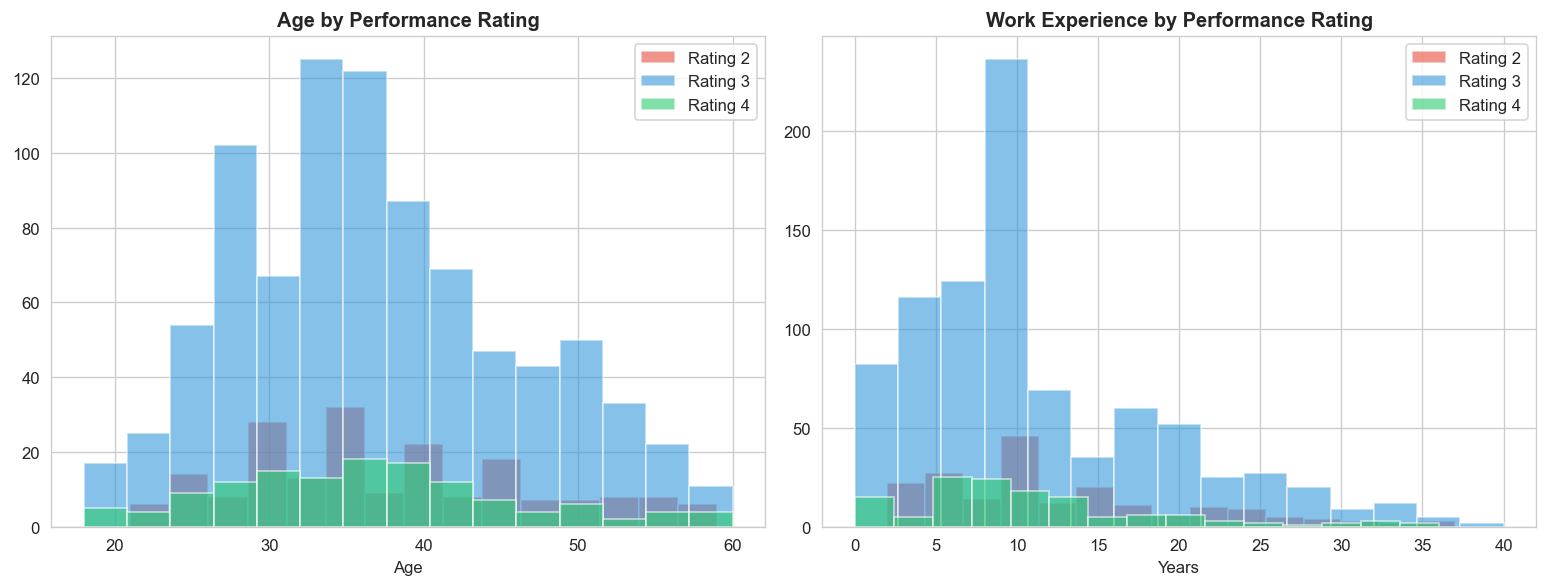

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
colors_map = {2:'#e74c3c', 3:'#3498db', 4:'#2ecc71'}
for rating, color in colors_map.items():
    sub = df[df['PerformanceRating']==rating]
    axes[0].hist(sub['Age'], bins=15, alpha=0.6, color=color, label=f'Rating {rating}')
    axes[1].hist(sub['TotalWorkExperienceInYears'], bins=15, alpha=0.6, color=color, label=f'Rating {rating}')
axes[0].set_title('Age by Performance Rating', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].legend()
axes[1].set_title('Work Experience by Performance Rating', fontweight='bold')
axes[1].set_xlabel('Years'); axes[1].legend()
plt.tight_layout()
plt.savefig('../../data/processed/fig_age_experience.png', bbox_inches='tight')
plt.show()

## 7. EDA Summary

**Key Findings:**
- 72.8% employees rated Good (3), 16.2% Low (2), 11% Excellent (4) — class imbalance needs SMOTE
- Development & Data Science: highest avg performance
- Human Resources & Finance: most Low performers
- Salary Hike %, Environment Satisfaction, Years Since Promotion are the strongest correlates with PerformanceRating
- Overtime does not guarantee better performance — polarized results
- Work-Life Balance score of 3 (balanced) links to best outcomes